# Exploratory Data Analysis on annual 'characteristics' data

In [1]:
# imports 
import os
import pandas as pd
from pathlib import Path
import sys

ROOT = Path().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT / "src"))

# print(sys.path)
import utils.file_helper as fh
import utils.general_helper as gh
from core.session import session
from core.logger import create_logger

import importlib.util
from pathlib import Path

"""
p = Path("/home/robfra/0_Portfolio_Projekte/Road_accidents/src/utils/file_helper.py")
print("exists:", p.exists(), "size:", p.stat().st_size if p.exists() else None)

spec = importlib.util.find_spec("utils.file_helper")
print("spec:", spec)
"""

'\np = Path("/home/robfra/0_Portfolio_Projekte/Road_accidents/src/utils/file_helper.py")\nprint("exists:", p.exists(), "size:", p.stat().st_size if p.exists() else None)\n\nspec = importlib.util.find_spec("utils.file_helper")\nprint("spec:", spec)\n'

In [2]:
# functions


def detect_delimiter(path: str) -> str:
    with open(path, encoding="latin1") as f:
        header = f.readline()
    if "\t" in header:
        return "\t"
    elif ";" in header:
        return ";"
    elif "," in header:
        return ","
    else:
        raise ValueError(f"Unknown delimiter in {path}")


def fix_single_column_df(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[1] != 1:
        return df
        
    header_raw = df.columns[0]
    # print("cols to fix:\t", df.columns, "\n", col)

    if "," in header_raw:
        sep = ","
        # return df[col].str.split(",", expand=True)
    elif "\t" in header_raw:
        sep = "\t"
        # return df[col].str.split("\t", expand=True)
    else:
        # nothing to unpack
        return df
        # raise ValueError("Single column but no obvious delimiter")
    
    # Create header list
    header = [h.strip() for h in header_raw.split(sep)]

    # Split the ONLY data column into multiple columns
    data = df.iloc[:, 0].astype(str).str.split(sep, expand=True)

    # If file has trailing separators, data may have more cols than header
    if data.shape[1] > len(header):
        # keep only expected cols; drop the rest (usually empty)
        data = data.iloc[:, :len(header)]
        
    elif data.shape[1] < len(header):
        # data has fewer cols than header -> pad with NA
        for _ in range(len(header) - data.shape[1]):
            data[data.shape[1]] = pd.NA

    data.columns = header

    # Normalize common id column variants
    data = data.rename(columns={"Accident_Id": "Num_Acc", "accident_id": "Num_Acc"})

    return data


def read_french_csv_smart(path: str) -> pd.DataFrame:
    sep = detect_delimiter(path)
    df = pd.read_csv(
        path,
        sep=sep,
        encoding="latin1",
        decimal=",",
        engine="python",
        on_bad_lines="skip",
        # low_memory=False
            )

    return df

def load_files_from_folder(folder):
    folder = Path(folder)
    
    df_list = []
    for file in folder.iterdir():
        df = read_french_csv_smart(file)
        df = fix_single_column_df(df)
        df_re = df.rename(columns={"Accident_Id": "Num_Acc", "accident_id": "Num_Acc"})
        
        print("shape:\t", df_re.shape)
        print("columns:\t", df_re.columns)
        print("head:\n", df_re.head(3))
        print()
        df_list.append(df_re)
        
    return df_list


In [3]:
# load logger
log_name= "EDA_CHARACTERISTICS"
name_logfile = "eda_characteristics"

logger = create_logger(name=log_name,
                        file_name=name_logfile)
session.logger = logger

# load dataframes into list

gh.load_env_vars()
folder = os.getenv("PATH_RAW")
folder_charac = f"{folder}/Eigenschaften_characteristics"

charac_dfs = fh.load_files_from_folder(folder_charac)
print("length dict:\t", len(charac_dfs.keys()))


Variables from .env.session loaded
Variables from .env loaded
Variables from .env.session loaded
2026-02-22 19:34:38,741 [INFO] EDA_CHARACTERISTICS: shape:	(87026, 16)
2026-02-22 19:34:38,747 [INFO] EDA_CHARACTERISTICS: columns:	Index(['Num_Acc', 'an', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm',
       'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep'],
      dtype='str')
2026-02-22 19:34:38,769 [INFO] EDA_CHARACTERISTICS: head:
        Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col   com  \
0  200500000001   5     1    12  1900    3    2    1    1    3  11.0   
1  200500000002   5     1    21  1600    1    2    1    1    1  51.0   
2  200500000003   5     1    21  1845    3    1    1    2    1  51.0   

            adr gps        lat      long  dep  
0         CD41B   M  5051500.0  294400.0  590  
1  rue de Lille   M  5053700.0  280200.0  590  
2           NaN   M  5054600.0  280000.0  590  
2026-02-22 19:34:44,416 [INFO] EDA_CHARACTERISTICS: shape:	(82993, 16)
2026-02-

## Output (exemple): 

```
Variables from .env.session loaded
Variables from .env loaded
Variables from .env.session loaded

SHAPE:	 (87026, 16)

COLUMNS:	 Index(['Num_Acc', 'an', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm',
       'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep'],
      dtype='str')

HEAD:
         Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col   com  \
0  200500000001   5     1    12  1900    3    2    1    1    3  11.0   
1  200500000002   5     1    21  1600    1    2    1    1    1  51.0   
2  200500000003   5     1    21  1845    3    1    1    2    1  51.0   

            adr gps        lat      long  dep  
0         CD41B   M  5051500.0  294400.0  590  
1  rue de Lille   M  5053700.0  280200.0  590  
2           NaN   M  5054600.0  280000.0  590  

[...]

length list:	 20
```


In [4]:
# EDA on loaded dfs

fh.df_preview(charac_dfs)
    

2026-02-22 19:36:01,593 [INFO] EDA_CHARACTERISTICS: 
2026-02-22 19:36:01,604 [INFO] EDA_CHARACTERISTICS: ==================================================
2026-02-22 19:36:01,605 [INFO] EDA_CHARACTERISTICS: --- EDA RAW DATA (df_1) --- 2026-02-22 19:36:01 ---
2026-02-22 19:36:01,607 [INFO] EDA_CHARACTERISTICS: ==================================================

2026-02-22 19:36:01,608 [INFO] EDA_CHARACTERISTICS: SHAPE:	 (87026, 16)
2026-02-22 19:36:01,649 [INFO] EDA_CHARACTERISTICS: INFO:
 <class 'pandas.DataFrame'>
RangeIndex: 87026 entries, 0 to 87025
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Num_Acc  87026 non-null  int64  
 1   an       87026 non-null  int64  
 2   mois     87026 non-null  int64  
 3   jour     87026 non-null  int64  
 4   hrmn     87026 non-null  int64  
 5   lum      87026 non-null  int64  
 6   agg      87026 non-null  int64  
 7   int      87026 non-null  int64  
 8   atm      87026 non-nul

## Output (exemple): 

```
2026-02-22 19:36:01,593 [INFO] EDA_CHARACTERISTICS: 
2026-02-22 19:36:01,604 [INFO] EDA_CHARACTERISTICS: ==================================================
2026-02-22 19:36:01,605 [INFO] EDA_CHARACTERISTICS: --- EDA RAW DATA (df_1) --- 2026-02-22 19:36:01 ---
2026-02-22 19:36:01,607 [INFO] EDA_CHARACTERISTICS: ==================================================

2026-02-22 19:36:01,608 [INFO] EDA_CHARACTERISTICS: SHAPE:	 (87026, 16)
2026-02-22 19:36:01,649 [INFO] EDA_CHARACTERISTICS: INFO:
 <class 'pandas.DataFrame'>
RangeIndex: 87026 entries, 0 to 87025
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Num_Acc  87026 non-null  int64  
 1   an       87026 non-null  int64  
 2   mois     87026 non-null  int64  
 3   jour     87026 non-null  int64  
 4   hrmn     87026 non-null  int64  
 5   lum      87026 non-null  int64  
 6   agg      87026 non-null  int64  
 7   int      87026 non-null  int64  
 8   atm      87026 non-null  int64  
 9   col      87026 non-null  int64  
 10  com      87024 non-null  float64
 11  adr      70238 non-null  str    
 12  gps      27037 non-null  str    
 13  lat      26943 non-null  float64
 14  long     26943 non-null  float64
 15  dep      87026 non-null  int64  
dtypes: float64(3), int64(11), str(2)
memory usage: 11.9 MB

2026-02-22 19:36:01,658 [INFO] EDA_CHARACTERISTICS: TOTAL NAN COUNT:
 Num_Acc        0
an             0
mois           0
jour           0
hrmn           0
lum            0
agg            0
int            0
atm            0
col            0
com            2
adr        16788
gps        59989
lat        60083
long       60083
dep            0
dtype: int64
2026-02-22 19:36:01,662 [INFO] EDA_CHARACTERISTICS: HEAD:
         Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col    com  \
0  200500000001   5     1    12  1900    3    2    1    1    3   11.0   
1  200500000002   5     1    21  1600    1    2    1    1    1   51.0   
2  200500000003   5     1    21  1845    3    1    1    2    1   51.0   
3  200500000004   5     1     4  1615    1    1    1    1    5   82.0   
4  200500000005   5     1    10  1945    3    1    1    3    6  478.0   

            adr gps        lat      long  dep  
0         CD41B   M  5051500.0  294400.0  590  
1  rue de Lille   M  5053700.0  280200.0  590  
2           NaN   M  5054600.0  280000.0  590  
3           NaN   M  5098700.0  240800.0  590  
4           NaN   M  5096400.0  247500.0  590   

``` 

In [5]:
# merge dfs from df_list
# encoding_dict
encode_gov = {
            "Num_Acc": "id", 
            "jour": "day", 
            "mois": "month", 
            "an": "year",
            "hrmn": "time (hr:mn)",
            "lum": "light conditions",
            "dep": "department", 
            "com": "commune",
            "agg": "localisation", 
            "int": "intersection type",
            "atm": "weather",
            "col": "collision type",
            "adr": "postal address",
            "lat": "latitude",
            "long": "longitude",
                 }

charac_merge = pd.concat(charac_dfs.values())
charac_renamed = charac_merge.rename(columns=encode_gov)

fh.df_preview({"df_merged": charac_renamed})

2026-02-22 19:39:50,424 [INFO] EDA_CHARACTERISTICS: 
2026-02-22 19:39:50,425 [INFO] EDA_CHARACTERISTICS: ==================================================
2026-02-22 19:39:50,426 [INFO] EDA_CHARACTERISTICS: --- EDA RAW DATA (df_merged) --- 2026-02-22 19:39:50 ---
2026-02-22 19:39:50,428 [INFO] EDA_CHARACTERISTICS: ==================================================

2026-02-22 19:39:50,429 [INFO] EDA_CHARACTERISTICS: SHAPE:	 (1286097, 16)
2026-02-22 19:39:50,725 [INFO] EDA_CHARACTERISTICS: INFO:
 <class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   id                 1286097 non-null  int64  
 1   year               1286097 non-null  int64  
 2   month              1286097 non-null  int64  
 3   day                1286097 non-null  int64  
 4   time (hr:mn)       1286097 non-null  object 
 5   light conditions   1286097 non-null  int64  
 6 

## Output (exemple): 

```
2026-02-22 19:39:50,425 [INFO] EDA_CHARACTERISTICS: ==================================================
2026-02-22 19:39:50,426 [INFO] EDA_CHARACTERISTICS: --- EDA RAW DATA (df_merged) --- 2026-02-22 19:39:50 ---
2026-02-22 19:39:50,428 [INFO] EDA_CHARACTERISTICS: ==================================================

2026-02-22 19:39:50,429 [INFO] EDA_CHARACTERISTICS: SHAPE:	 (1286097, 16)
2026-02-22 19:39:50,725 [INFO] EDA_CHARACTERISTICS: INFO:
 <class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   id                 1286097 non-null  int64  
 1   year               1286097 non-null  int64  
 2   month              1286097 non-null  int64  
 3   day                1286097 non-null  int64  
 4   time (hr:mn)       1286097 non-null  object 
 5   light conditions   1286097 non-null  int64  
 6   localisation       1286097 non-null  int64  
 7   intersection type  1286097 non-null  int64  
 8   weather            1286024 non-null  float64
 9   collision type     1286078 non-null  float64
 10  commune            1286095 non-null  object 
 11  postal address     1137889 non-null  str    
 12  gps                480052 non-null   str    
 13  latitude           799029 non-null   float64
 14  longitude          799025 non-null   object 
 15  department         1286097 non-null  object 
dtypes: float64(3), int64(7), object(4), str(2)
memory usage: 187.6+ MB

2026-02-22 19:39:50,972 [INFO] EDA_CHARACTERISTICS: TOTAL NAN COUNT:
 id                        0
year                      0
month                     0
day                       0
time (hr:mn)              0
light conditions          0
localisation              0
intersection type         0
weather                  73
collision type           19
commune                   2
postal address       148208
gps                  806045
latitude             487068
longitude            487072
department                0
dtype: int64
2026-02-22 19:39:50,976 [INFO] EDA_CHARACTERISTICS: HEAD:
              id  year  month  day time (hr:mn)  light conditions  \
0  200500000001     5      1   12         1900                 3   
1  200500000002     5      1   21         1600                 1   
2  200500000003     5      1   21         1845                 3   
3  200500000004     5      1    4         1615                 1   
4  200500000005     5      1   10         1945                 3   

   localisation  intersection type  weather  collision type commune  \
0             2                  1      1.0             3.0    11.0   
1             2                  1      1.0             1.0    51.0   
2             1                  1      2.0             1.0    51.0   
3             1                  1      1.0             5.0    82.0   
4             1                  1      3.0             6.0   478.0   

  postal address gps   latitude longitude department  
0          CD41B   M  5051500.0  294400.0        590  
1   rue de Lille   M  5053700.0  280200.0        590  
2            NaN   M  5054600.0  280000.0        590  
3            NaN   M  5098700.0  240800.0        590  
4            NaN   M  5096400.0  247500.0        590   

``` 

In [10]:
# value_counts per column
cols_interest = ["year",
                "day", "time (hr:mn)", 
                "light conditions", "department",
                "commune"]


for col in charac_renamed.columns:
    common_values = charac_renamed[col].value_counts(normalize=True, ascending=False)
    
    print("10 least common values\n", common_values[-10:])
    if col in cols_interest:
        print("\n10 most common values:\n", common_values[:10])
    print()

"""
year:
5     0.067667
7     0.065197
6     0.064531
8     0.059690
9     0.057856



10 least common values
 id
202400054393    7.775463e-07
202400054394    7.775463e-07
202400054395    7.775463e-07
202400054396    7.775463e-07
202400054397    7.775463e-07
202400054398    7.775463e-07
202400054399    7.775463e-07
202400054400    7.775463e-07
202400054401    7.775463e-07
202400054402    7.775463e-07
Name: proportion, dtype: float64

10 least common values
 year
16      0.046211
2019    0.045751
15      0.045606
13      0.045406
18      0.044929
2021    0.043945
2022    0.043000
2023    0.042627
2024    0.042300
2020    0.037123
Name: proportion, dtype: float64

10 most common values:
 year
5     0.067667
7     0.065197
6     0.064531
8     0.059690
9     0.057856
10    0.053945
11    0.052075
12    0.048402
17    0.047198
14    0.046539
Name: proportion, dtype: float64

10 least common values
 month
9     0.092488
7     0.090351
5     0.085798
11    0.084948
12    0.081692
4     0.077854
3     0.077140
1     0.076538
8     0.075871
2     0.067983
Name: proportion, dtype

In [2]:
# sanity checks
import sys
print("executable:\t", sys.executable)

import site
print("site:\t", site.getsitepackages())

executable:	 /home/robfra/0_Portfolio_Projekte/Road_accidents/.venv/bin/python
site:	 ['/home/robfra/0_Portfolio_Projekte/Road_accidents/.venv/lib/python3.12/site-packages']


In [9]:
# 
import pandas as pd

# kaggle dataset
f_path_1 = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/_from_kaggle/caracteristics.csv"

# data.gov dataset
f_path_2 = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/_from_kaggle/gov_caract-2023.csv"

df_1 = pd.read_csv(f_path_1, encoding="latin1", low_memory=False) 
df_2 = pd.read_csv(f_path_2, encoding="latin1", sep=";", low_memory=False) 

for name, df in zip(["kaggle", "data-gov"],
                    [df_1, df_2]):
    print(name, "\n", df.head(), "\n")
    df.info()
    print()
    


kaggle 
         Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col    com  \
0  201600000001  16     2     1  1445    1    2    1  8.0  3.0    5.0   
1  201600000002  16     3    16  1800    1    2    6  1.0  6.0    5.0   
2  201600000003  16     7    13  1900    1    1    1  1.0  6.0   11.0   
3  201600000004  16     8    15  1930    2    2    1  7.0  3.0  477.0   
4  201600000005  16    12    23  1100    1    2    3  1.0  3.0   11.0   

                   adr gps  lat long  dep  
0   46, rue Sonneville   M  0.0    0  590  
1  1a rue du cimetière   M  0.0    0  590  
2                  NaN   M  0.0    0  590  
3   52 rue victor hugo   M  0.0    0  590  
4     rue Joliot curie   M  0.0    0  590   

<class 'pandas.DataFrame'>
RangeIndex: 839985 entries, 0 to 839984
Data columns (total 16 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Num_Acc  839985 non-null  int64  
 1   an       839985 non-null  int64  
 2   mois     839985 non-null 

# CARACTERISTICS :

Num_Acc : Accident ID

jour : Day of the accident

mois : Month of the accident

an : Year of the accident

hrmn : Time of the accident in hour and minutes (hhmm)

lum : Lighting : lighting conditions in which the accident occurred
1 - Full day
2 - Twilight or dawn
3 - Night without public lighting
4 - Night with public lighting not lit
5 - Night with public lighting on

dep : Departmeent : INSEE Code (National Institute of Statistics and Economic Studies) of the departmeent followed by a 0 (201 Corse-du-Sud - 202 Haute-Corse)

com : Municipality: The commune number is a code given by INSEE. The code has 3 numbers set to the right.

Localisation :
1 - Out of agglomeration
2 - In built-up areas

int : Type of Intersection :
1 - Out of intersection
2 - Intersection in X
3 - Intersection in T
4 - Intersection in Y
5 - Intersection with more than 4 branches
6 - Giratory
7 - Place
8 - Level crossing
9 - Other intersection

atm : Atmospheric conditions:
1 - Normal
2 - Light rain
3 - Heavy rain
4 - Snow - hail
5 - Fog - smoke
6 - Strong wind - storm
7 - Dazzling weather
8 - Cloudy weather
9 - Other

col : Type of collision:
1 - Two vehicles - frontal
2 - Two vehicles - from the rear
3 - Two vehicles - by the side
4 - Three vehicles and more - in chain
5 - Three or more vehicles - multiple collisions
6 - Other collision
7 - Without collision

adr : Postal address: variable filled in for accidents occurring in built-up areas

gps : GPS coding: 1 originator character:
M = Métropole
A = Antilles (Martinique or Guadeloupe)
G = Guyane
R = Réunion
Y = Mayotte

Geographic coordinates in decimal degrees:
lat : Latitude
long : Longitude

In [ ]:
# kaggle

# kaggle dataset
f_path_1 = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/_from_kaggle/caracteristics.csv"

encode_kaggle = {
            "Num_Acc": "id", 
            "an": "year",
            "mois": , 
            "jour": , 
            "hrmn": ,
            "lum": ,
            "agg": , 
            "int": ,
            "atm": ,
            "col": ,
            "com": ,
            "adr": ,
            "gps": "gps_encoding",
            "lat": ,
            "long": ,
            "dep": 
                 }

In [3]:
## load data


shape:	 (87026, 16)
columns:	 Index(['Num_Acc', 'an', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm',
       'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep'],
      dtype='str')
head:
         Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col   com  \
0  200500000001   5     1    12  1900    3    2    1    1    3  11.0   
1  200500000002   5     1    21  1600    1    2    1    1    1  51.0   
2  200500000003   5     1    21  1845    3    1    1    2    1  51.0   

            adr gps        lat      long  dep  
0         CD41B   M  5051500.0  294400.0  590  
1  rue de Lille   M  5053700.0  280200.0  590  
2           NaN   M  5054600.0  280000.0  590  

shape:	 (82993, 16)
columns:	 Index(['Num_Acc', 'an', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm',
       'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep'],
      dtype='str')
head:
         Num_Acc  an  mois  jour  hrmn  lum  agg  int  atm  col  com  \
0  200600000001   6     1     4  1545    1    2    2    1    3   53

## Output:

```
shape:	 (1286097, 16)
columns:	 Index(['id', 'year', 'month', 'day', 'time (hr:mn)', 'light conditions',
       'localisation', 'intersection type', 'weather', 'collision type',
       'commune', 'postal address', 'gps', 'latitude', 'longitude',
       'department'],
      dtype='str')
      
head:
              id  year  month  day time (hr:mn)  light conditions  \
0  200500000001     5      1   12         1900                 3   
1  200500000002     5      1   21         1600                 1   
2  200500000003     5      1   21         1845                 3   

   localisation  intersection type  weather  collision type commune  \
0             2                  1      1.0             3.0    11.0   
1             2                  1      1.0             1.0    51.0   
2             1                  1      2.0             1.0    51.0   

  postal address gps   latitude longitude department  
0          CD41B   M  5051500.0  294400.0        590  
1   rue de Lille   M  5053700.0  280200.0        590  
2            NaN   M  5054600.0  280000.0        590  

<class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   id                 1286097 non-null  int64  
 1   year               1286097 non-null  int64  
 2   month              1286097 non-null  int64  
 3   day                1286097 non-null  int64  
 4   time (hr:mn)       1286097 non-null  object 
 5   light conditions   1286097 non-null  int64  
 6   localisation       1286097 non-null  int64  
 7   intersection type  1286097 non-null  int64  
 8   weather            1286024 non-null  float64
 9   collision type     1286078 non-null  float64
 10  commune            1286095 non-null  object 
 11  postal address     1137889 non-null  str    
 12  gps                480052 non-null   str    
 13  latitude           799029 non-null   float64
 14  longitude          799025 non-null   object 
 15  department         1286097 non-null  object 
dtypes: float64(3), int64(7), object(4), str(2)
memory usage: 166.8+ MB

```

In [5]:
# (3) correct dtypes 
for col in ["commune", "department"]:
    charac_renamed[col] = (
                    charac_renamed[col]
                    .astype(str)
                    .str.strip()
                    .replace({"nan": pd.NA})
                    .astype("category")
                        )

charac_renamed["longitude"] = (
                    charac_renamed["longitude"]
                    .astype(str)
                    .str.replace(",", ".", regex=False)
                    .str.strip()
                    .replace({"": pd.NA, "nan": pd.NA})
                        )

for col in ["longitude", "latitude"]:
    charac_renamed[col] = pd.to_numeric(
                    charac_renamed[col],
                    errors="coerce"
                        )

print("INFO AFTER RENAMING")
charac_renamed.info()
print()

percs = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

print("DESCRIPTIVE STATISTICS 'LONGITUDE' + 'LATITUDE'\n", 
      charac_renamed[["longitude", "latitude"]].describe(percentiles=percs).round(3), "\n")

print("DESCRIPTIVE STATISTICS 'DEPARTMENT' + 'COMMUNE'")
print(charac_renamed[["department", "commune"]].describe().round(3))
for col in ["department", "commune"]:
    print(col) # harac_renamed[col].)
    print("MODE", charac_renamed[col].mode())
    print("TOP 20:\n", charac_renamed[col].value_counts().head(20), "\n")
    print("BOTTOM 20:\n", charac_renamed[col].value_counts().tail(20), "\n")

INFO AFTER RENAMING
<class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   id                 1286097 non-null  int64   
 1   year               1286097 non-null  int64   
 2   month              1286097 non-null  int64   
 3   day                1286097 non-null  int64   
 4   time (hr:mn)       1286097 non-null  object  
 5   light conditions   1286097 non-null  int64   
 6   localisation       1286097 non-null  int64   
 7   intersection type  1286097 non-null  int64   
 8   weather            1286024 non-null  float64 
 9   collision type     1286078 non-null  float64 
 10  commune            1286095 non-null  category
 11  postal address     1137889 non-null  str     
 12  gps                480052 non-null   str     
 13  latitude           799029 non-null   float64 
 14  longitude          795816 non-null   float64 
 15  department   



```
INFO AFTER RENAMING
<class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1286097 non-null  int64   
 1   year               1286097 non-null  int64   
 2   month              1286097 non-null  int64   
 3   day                1286097 non-null  int64   
 4   time (hr:mn)       1286097 non-null  object  
 5   light conditions   1286097 non-null  int64   
 6   localisation       1286097 non-null  int64   
 7   intersection type  1286097 non-null  int64   
 8   weather            1286024 non-null  float64 
 9   collision type     1286078 non-null  float64 
 10  commune            1286095 non-null  category
 11  postal address     1137889 non-null  str     
 12  gps                480052 non-null   str     
 13  latitude           799029 non-null   float64 
 14  longitude          795816 non-null   float64 
 15  department         1286097 non-null  category     
dtypes: category(2), datetime64[ns](1), float64(4), int64(7), str(2)
memory usage: 152.3 MB

DESCRIPTIVE STATISTICS 'LONGITUDE' + 'LATITUDE'
           longitude     latitude
count  7.958160e+05   799029.000
mean   1.555717e+06  1920826.755
std    9.026938e+08  2302930.158
min   -5.246000e+05      -61.426
1%    -3.377012e+05      -12.787
5%    -9.612250e+04        0.000
10%   -3.906000e+00        0.000
25%    0.000000e+00       43.631
50%    2.550000e+00       48.881
75%    2.256460e+05  4613730.000
90%    4.835790e+05  4882970.000
95%    5.864490e+05  4901000.000
99%    7.743976e+05  5019900.000
max    6.128500e+11  5564823.000 

DESCRIPTIVE STATISTICS 'DEPARTMENT' + 'COMMUNE'
       department  commune
count     1286097  1286095
unique        204    26174
top           750       55
freq        99021    33591

DEPARTMENT
TOP 20:
 department
750    99021
130    59442
930    39476
920    36409
940    34658
60     33946
690    30331
75     29430
590    25899
330    24640
910    20443
93     16595
780    16384
310    16100
340    15541
950    15300
830    14647
974    14629
13     14473
92     14367
Name: count, dtype: int64 

BOTTOM 20:
 department
09     701
36     695
52     678
55     655
46     604
08     510
1      474
48     444
23     300
7      265
5      252
3      248
4      230
2      210
978    192
9      124
8       91
977     87
986     62
975     19
Name: count, dtype: int64 

COMMUNE
TOP 20:
 commune
55     33591
88     13122
7      10775
113    10381
63     10123
116     9117
555     8827
117     8488
4       8091
112     7998
69      7310
118     7183
108     7086
109     6724
1       6692
172     6430
119     6227
120     6185
114     6029
18      5955
Name: count, dtype: int64 

BOTTOM 20:
 commune
952      1
95214    1
95254    1
95257    1
95271    1
95301    1
95303    1
95341    1
95429    1
95459    1
95483    1
95523    1
95541    1
95625    1
95633    1
95676    1
97211    1
98742    1
98749    1
N/C      1
Name: count, dtype: int64 
```

In [3]:
# load df_prep
folder = "/mnt/chromeos/GoogleDrive/MyDrive/1_Projekte_Datensätze/1_Projekte/4_accidents/data/data_processed" 
f_name = "df_period"

f_path = Path(folder) / f"{f_name}.parquet"
df = pd.read_parquet(f_path)

print(df.info())

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/chromeos/GoogleDrive/MyDrive/1_Projekte_Datensätze/1_Projekte/4_accidents/data/data_processed/df_period.parquet'



DF HEAD:
                                    0                1                2
h3_res5               85184093fffffff  85184093fffffff  85184093fffffff
period                        2001-10          2002-05          2002-08
n_accidents                         1                1                1
year                           2001.0           2002.0           2002.0
month                            10.0              5.0              8.0
weath_normal                      0.0              1.0              1.0
weath_l_rainy                     0.0              0.0              0.0
weath_h_rainy                     1.0              0.0              0.0
weath_snow_hail                   0.0              0.0              0.0
weath_foggy                       0.0              0.0              0.0
weath_stormy                      0.0              0.0              0.0
weath_dazzle                      0.0              0.0              0.0
weath_cloudy                      0.0              0.0              0.0
weath_other                       0.0              0.0              0.0
inter_no                          1.0              1.0              1.0
inter_X                           0.0              0.0              0.0
inter_T                           0.0              0.0              0.0
inter_Y                           0.0              0.0              0.0
inter_4+                          0.0              0.0              0.0
inter_gira                        0.0              0.0              0.0
inter_place                       0.0              0.0              0.0
inter_level                       0.0              0.0              0.0
inter_other                       0.0              0.0              0.0
coll_2_front                      0.0              0.0              0.0
coll_2_rear                       0.0              0.0              0.0
coll_2_side                       0.0              1.0              0.0
coll_3+_chain                     0.0              0.0              0.0
coll_3+_multi                     1.0              0.0              0.0
coll_other                        0.0              0.0              1.0
coll_no                           0.0              0.0              0.0
light_full_day                    0.0              1.0              1.0
light_dawn                        0.0              0.0              0.0
light_no_night_light              1.0              0.0              0.0
light_night_unlit                 0.0              0.0              0.0
light_night_lit                   0.0              0.0              0.0



In [ ]:
# wie sehen die leeren Spalten aus? 
"""
8   weather            1286024 non-null  float64 
9   collision type     1286078 non-null  float64 
10  commune            1286095 non-null  category
11  postal address     1137889 non-null  str     
12  gps                480052 non-null   str     
13  latitude           799029 non-null   float64 
14  longitude          795816 non-null   float64 
"""

cols_to_check = ["year", "department", 
                 "commune", "postal address",
                 "gps", "latitude",
                 "longitude"]

for col in ["weather", "collision type", 
            "commune", "postal address",
            "gps", "latitude",
            "longitude"]:
    df_filt = df[df[col] == pd.NA][cols_to_check]
    for col_filt in df_filt.columns:
        n_nan = df_filt[col_filt].isna().sum()
        print(f"n_nan in '{col_filt}':\t", n_nan)
    print(f"{col} - statistics:\n", df_filt.fillna(0).describe().round(3))
    print()

In [ ]:
# df.to_csv("")

# convert 'time'?

# num_feats = ["id", "year", 
#              "month", "day", 
#              "time", "longitude", 
#              "lattitude"]

# cat_feats = ["light conditions", "localisation", 
#             "intersection type", "weather", 
#              "collision type", "commune", 
#              "postal address", "gps", 
#              "department"]

# for col in num_feats:
    

# for col in cat_feats:
    
#     carac_re



In [6]:
## Phase A: Zeitdimension sauber machen (Pflicht)
# (1)
"""

charac_renamed["time (hr:mn)"] = pd.to_datetime(
                                            charac_renamed["time (hr:mn)"], 
                                            errors="coerce"
                                            )
"""
print("top20 values in 'time (hr:mn)':\n", 
      charac_renamed["time (hr:mn)"].value_counts().head(5))

# (2)
false_time = []

def parse_time_hhmm(s_in):
    if pd.isna(s_in):
        return pd.NA
    s = str(s_in).strip()
    
    if ":" in s: 
        parts = s.split(":")
        if len(parts) != 2:
            return pd.NA
        h, m = parts #s = "".join(s_out)
        if not (h.isdigit() and m.isdigit()):
            return pd.NA
        s = f"{h.zfill(2)}{m.zfill(2)}"
        
    if not s.isdigit():
        return pd.NA
    if len(s) == 4:
        hh = int(s[:2])
        mm = int(s[2:])
        
    elif len(s) == 3:
        hh = int(s[0])
        mm = int(s[1:])
        return f"0{s[0]}:{s[1:]}"

    else: 
        false_time.append((s_in, s))
        return pd.NA

    # hard validity checks
    if not (0 <= hh <= 23):
        return pd.NA
    if not (0 <= mm <= 59):
        return pd.NA
    return f"{hh:02d}:{mm:02d}"
    
charac_renamed["time_clean"] = charac_renamed["time (hr:mn)"].apply(parse_time_hhmm)

print("\ntop20 values in 'time_clean':\n", 
      charac_renamed["time_clean"].value_counts(dropna=False).head(5))

print("\nfalse_times:\n", false_time[:10])

print("\nratio of nan_values in 'time_clean':\t", charac_renamed["time_clean"].isna().mean())


top20 values in 'time (hr:mn)':
 time (hr:mn)
1800    14635
1730    13097
1700    13017
1830    12602
1900    11510
Name: count, dtype: int64

top20 values in 'time_clean':
 time_clean
18:00    18855
17:00    16777
17:30    16670
NaN      16436
18:30    16200
Name: count, dtype: int64

false_times:
 [(45, '45'), (15, '15'), (30, '30'), (45, '45'), (45, '45'), (15, '15'), (30, '30'), (15, '15'), (15, '15'), (45, '45')]

ratio of nan_values in 'time_clean':	 0.012779751449540742


## Output:

```
top20 values in 'time (hr:mn)':
 time (hr:mn)
1800    14635
1730    13097
1700    13017
1830    12602
1900    11510
Name: count, dtype: int64

top20 values in 'time_clean':
 time_clean
18:00    18855
17:00    16777
17:30    16670
NaN      16436
18:30    16200
Name: count, dtype: int64

false_times:
 [(45, '45'), (15, '15'), (30, '30'), (45, '45'), (45, '45'), (15, '15'), (30, '30'), (15, '15'), (15, '15'), (45, '45')]

ratio of nan_values in 'time_clean':	 0.0128 --> 1,28%
```

In [7]:
# (3)
charac_renamed["datetime"] = pd.to_datetime(
    charac_renamed[["year", "month", "day"]].astype(str).agg("-".join, axis=1)
    + " "
    + charac_renamed["time_clean"],
    errors="coerce"
)

print("ration of nan_values in 'datetime':\t", charac_renamed["datetime"].isna().mean())
print("\n", charac_renamed["datetime"].dt.year.describe())

# (4)
charac_renamed["hour"] = charac_renamed["datetime"].dt.hour
charac_renamed["weekday"] = charac_renamed["datetime"].dt.weekday
charac_renamed["is_weekend"] = charac_renamed["weekday"] >= 5

cols = ["hour", "weekday", "is_weekend", "datetime"]
print("HEAD:\n", charac_renamed[cols].head())

charac_renamed.info()

/tmp/ipykernel_22799/871176169.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  charac_renamed["datetime"] = pd.to_datetime(


ration of nan_values in 'datetime':	 0.012779751449540742

 count    1.269661e+06
mean     2.017127e+03
std      8.008748e+00
min      2.001000e+03
25%      2.011000e+03
50%      2.019000e+03
75%      2.023000e+03
max      2.031000e+03
Name: datetime, dtype: float64
HEAD:
    hour  weekday  is_weekend            datetime
0  19.0      1.0       False 2012-05-01 19:00:00
1  16.0      5.0        True 2021-05-01 16:00:00
2  18.0      5.0        True 2021-05-01 18:45:00
3  16.0      5.0        True 2004-05-01 16:15:00
4  19.0      5.0        True 2010-05-01 19:45:00
<class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1286097 non-null  int64         
 1   year               1286097 non-null  int64         
 2   month              1286097 non-null  int64         
 3   day                1286097 non-null  int64     

## Output:

```
ration of nan_values in 'datetime':	 0.0128 --> 1,28%

        year
count    1.269661e+06
mean     2.017127e+03
std      8.008748e+00
min      2.001000e+03
25%      2.011000e+03
50%      2.019000e+03
75%      2.023000e+03
max      2.031000e+03
Name: datetime, dtype: float64

HEAD:
    hour  weekday  is_weekend            datetime
0  19.0      1.0       False 2012-05-01 19:00:00
1  16.0      5.0        True 2021-05-01 16:00:00
2  18.0      5.0        True 2021-05-01 18:45:00
3  16.0      5.0        True 2004-05-01 16:15:00
4  19.0      5.0        True 2010-05-01 19:45:00

INFO:
Index: 1286097 entries, 0 to 54401
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1286097 non-null  int64         
 1   year               1286097 non-null  int64         
 2   month              1286097 non-null  int64         
 3   day                1286097 non-null  int64         
 4   time (hr:mn)       1286097 non-null  object        
 5   light conditions   1286097 non-null  int64         
 6   localisation       1286097 non-null  int64         
 7   intersection type  1286097 non-null  int64         
 8   weather            1286024 non-null  float64       
 9   collision type     1286078 non-null  float64       
 10  commune            1286095 non-null  category      
 11  postal address     1137889 non-null  str           
 12  gps                480052 non-null   str           
 13  latitude           799029 non-null   float64       
 14  longitude          795816 non-null   float64       
 15  department         1286097 non-null  category      
 16  time_clean         1269661 non-null  str           
 17  datetime           1269661 non-null  datetime64[us]
 18  hour               1269661 non-null  float64       
 19  weekday            1269661 non-null  float64       
 20  is_weekend         1286097 non-null  bool          
dtypes: bool(1), category(2), datetime64[us](1), float64(6), int64(7), object(1), str(3)
memory usage: 193.8+ MB

In [10]:
["department", "commune", "year", "month"]

HEAD:
    hour  weekday  is_weekend            datetime
0  19.0      1.0       False 2012-05-01 19:00:00
1  16.0      5.0        True 2021-05-01 16:00:00
2  18.0      5.0        True 2021-05-01 18:45:00
3  16.0      5.0        True 2004-05-01 16:15:00
4  19.0      5.0        True 2010-05-01 19:45:00
<class 'pandas.DataFrame'>
Index: 1286097 entries, 0 to 54401
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1286097 non-null  int64         
 1   year               1286097 non-null  int64         
 2   month              1286097 non-null  int64         
 3   day                1286097 non-null  int64         
 4   time (hr:mn)       1286097 non-null  object        
 5   light conditions   1286097 non-null  int64         
 6   localisation       1286097 non-null  int64         
 7   intersection type  1286097 non-null  int64         
 8   weather            1286024 no

In [ ]:
# Phase B: Geodimension prüfen & entscheiden
import numpy as np

geo_valid = charac_renamed["latitude"].notna() & charac_renamed["longitude"].notna()
print("[AT START] ratio 'geo_valid'\t", geo_valid.mean().round(4))

"""
Interpretation:
≥ 60 % → Geo ist tragfähig
40–60 % → eingeschränkt nutzbar
< 40 % → GPS nur Zusatz, keine Hauptachse

👉 Sag mir die Zahl – das ist eine harte Weiche.
"""

percs = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

# B2️⃣ Plausibilitätscheck (Frankreich)
print("description of 'geo_valid':\n", charac_renamed.loc[geo_valid, ["latitude", "longitude"]].describe(percentiles=percs))

extreme_long = charac_renamed[charac_renamed["longitude"] >= 7.743975e+05]
print("\n'extreme'-longitude rows:\t", len(extreme_long))
print("HEAD:\n", extreme_long[["department", "gps", "commune", "year", "month"]].head())
for col in ["department", "gps", "commune", "year", "month"]:
    print(f"value_counts in '{col}'\n", extreme_long[col].value_counts().head(10))
"""
Erwartung:
Latitude ~ 41–51
Longitude ~ −5 bis +10
"""

'''
plot_path = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/plots/eda/scatter_geodata.png"
sample = charac_renamed.loc[geo_valid].sample(20_000, random_state=42)

plt.scatter(
    sample["long_norm"],
    sample["lat_norm"],
    s=1,
    alpha=0.3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident locations (sample)")
plt.savefig(plot_path)
plt.show()
'''

DOM_DEPARTMENTS = {"971", "972", "973", "974", "976"}
'''
METRO_DEPARTMENTS = {
    d for d in carac_re["department"].astype(str).unique()
    if d not in DOM_DEPARTMENTS
}
'''
charac_renamed["region_type"] = np.where(
    charac_renamed["department"].astype(str).isin(DOM_DEPARTMENTS),
    "dom",
    "metropole"
)

charac_red =  charac_renamed[charac_renamed["region_type"]=="metropole"].copy()

print("[POST-REDUCTION] Ratio 'geo-valid' data", (charac_red["latitude"].notna() 
                                                & charac_red["longitude"].notna()).mean().round(4))

[AT START] ratio 'geo_valid'	 0.6188
description of 'geo_valid':
            latitude     longitude
count  7.958160e+05  7.958160e+05
mean   1.928582e+06  1.555717e+06
std    2.304331e+06  9.026938e+08
min   -6.142566e+01 -5.246000e+05
1%    -1.278826e+01 -3.377012e+05
5%     0.000000e+00 -9.612250e+04
10%    0.000000e+00 -3.906128e+00
25%    4.365845e+01  0.000000e+00
50%    4.888324e+01  2.550110e+00
75%    4.615853e+06  2.256460e+05
90%    4.883050e+06  4.835790e+05
95%    4.901230e+06  5.864490e+05
99%    5.020500e+06  7.743975e+05
max    5.564823e+06  6.128500e+11

'extreme'-longitude rows:	 7959
HEAD:
      department gps commune  year  month
1115        670   M    46.0     5      1
1116        670   M   345.0     5      1
1130        670   M   151.0     5      1
1135        670   M   544.0     5      1
1136        670   M   288.0     5      1
value_counts in 'department'
 department
974    1588
670    1318
201    1309
202    1279
973    1155
971     454
976     418
972     401
6

## Output:
```
[AT START] ratio 'geo_valid'	 0.6188  --> 61,88 %

description of 'geo_valid':
            latitude     longitude
count  7.958160e+05  7.958160e+05
mean   1.928582e+06  1.555717e+06
std    2.304331e+06  9.026938e+08
min   -6.142566e+01 -5.246000e+05
1%    -1.278826e+01 -3.377012e+05
5%     0.000000e+00 -9.612250e+04
10%    0.000000e+00 -3.906128e+00
25%    4.365845e+01  0.000000e+00
50%    4.888324e+01  2.550110e+00
75%    4.615853e+06  2.256460e+05
90%    4.883050e+06  4.835790e+05
95%    4.901230e+06  5.864490e+05
99%    5.020500e+06  7.743975e+05
max    5.564823e+06  6.128500e+11

```
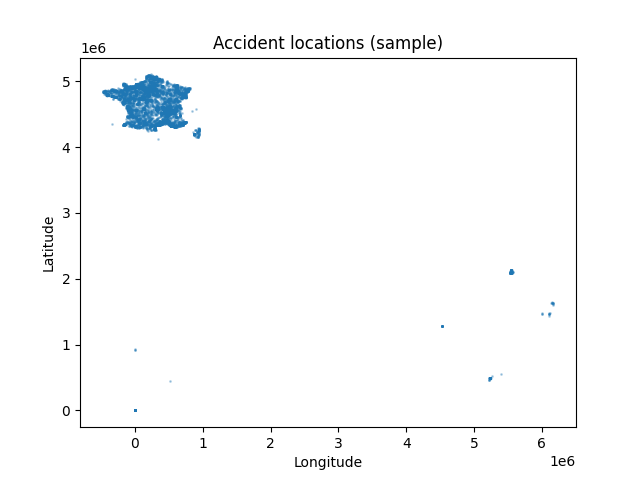

```
'extreme'-longitude rows:	 7959

HEAD:
      department commune  year  month
1115        670    46.0     5      1
1116        670   345.0     5      1
1130        670   151.0     5      1
1135        670   544.0     5      1
1136        670   288.0     5      1

value_counts in 'department'
 department
974    1588
670    1318
201    1309
202    1279
973    1155
971     454
976     418
972     401
690       6
590       4
Name: count, dtype: int64

value_counts in 'commune'
 commune
302    969
482    637
4      621
416    527
611    350
33     254
407    248
209    223
411    221
247    142
Name: count, dtype: int64

value_counts in 'year'
 year
18    2859
17    2029
15    1020
16     725
8      206
5      205
7      198
6      160
13     150
12     149
Name: count, dtype: int64

value_counts in 'month'
 month
7     787
6     781
9     748
8     743
5     718
10    701
12    699
4     666
11    640
3     562
Name: count, dtype: int64

[POST-REDUCTION] Ratio 'geo-valid' data 0.6172
```

[POST-NORMALISATION] Ratio 'geo-valid' data 0.5124


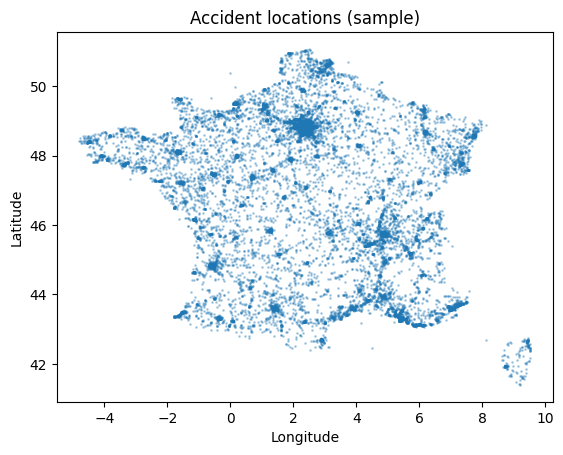

In [14]:
# NORMALISATION (to metropol France; exclude DOM-TOM)

def normalize_lat_lon(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA, pd.NA

    # already plausible
    if 40 <= lat <= 52 and -6 <= lon <= 11:
        return lat, lon

    # try scaled versions
    for scale in (1e5, 1e6):
        lat_s = lat / scale
        lon_s = lon / scale
        if 40 <= lat_s <= 52 and -6 <= lon_s <= 11:
            return lat_s, lon_s

    return pd.NA, pd.NA

norm = charac_red.apply(
    lambda r: normalize_lat_lon(r["latitude"], r["longitude"]),
    axis=1,
    result_type="expand"
)

geo_valid_new = (charac_red["lat_norm"].notna() & charac_red["lon_norm"].notna())

charac_red[["lat_norm", "lon_norm"]] = norm
print("[POST-NORMALISATION] Ratio 'geo-valid' data", geo_valid_new.mean().round(4))

# exemple DataViz
import matplotlib.pyplot as plt

plot_path = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/plots/eda/scatter_geodata_norm.png"
sample = charac_red.loc[geo_valid_new].sample(20_000, random_state=42)

plt.scatter(
    sample["lon_norm"],
    sample["lat_norm"],
    s=1,
    alpha=0.3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident locations (sample)")
plt.savefig(plot_path)
plt.show()


## Output:
```
[POST-NORMALISATION] Ratio 'geo-valid' data  0.5124 --> 51,24%

```
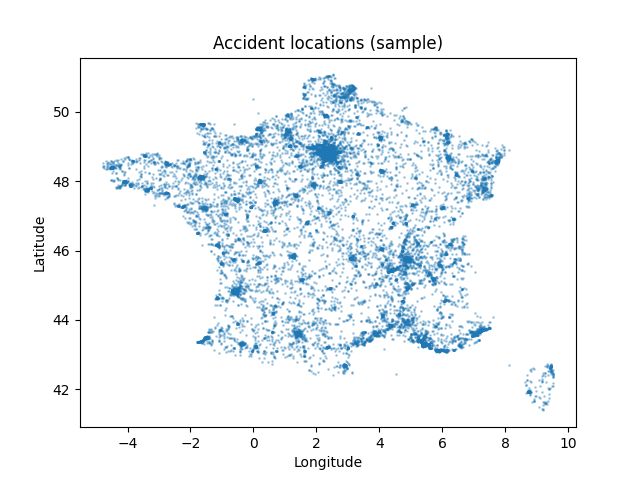


In [17]:

print("HEAD\n", charac_red.head(5))
print("\nCOLUMNS\n", charac_red.columns)

cols_needed = ['id', 'year', 'month', 'day', 'hour', 'time_clean', 'weekday', 'is_weekend',
               'light conditions',
               'localisation', 'intersection type', 'weather', 'collision type',
               'commune', 'department', 'lat_norm', 'lon_norm']
            
charac_final = charac_red[cols_needed].copy()

df_path = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/data_processed/character_final.csv"
charac_final.to_csv(df_path)

df_path_re = "/home/robfra/0_Portfolio_Projekte/Road_accidents/data/data_processed/character_merged.csv"
charac_renamed.to_csv(df_path_re)
'''
COLUMNS
 Index(['id', 'year', 'month', 'day', 'time (hr:mn)', 'light conditions',
       'localisation', 'intersection type', 'weather', 'collision type',
       'commune', 'postal address', 'gps', 'latitude', 'longitude',
       'department', 'time_clean', 'datetime', 
       'region_type', ],
      dtype='str')
      
'''

HEAD
              id  year  month  day time (hr:mn)  light conditions  \
0  200500000001     5      1   12         1900                 3   
1  200500000002     5      1   21         1600                 1   
2  200500000003     5      1   21         1845                 3   
3  200500000004     5      1    4         1615                 1   
4  200500000005     5      1   10         1945                 3   

   localisation  intersection type  weather  collision type  ... longitude  \
0             2                  1      1.0             3.0  ...  294400.0   
1             2                  1      1.0             1.0  ...  280200.0   
2             1                  1      2.0             1.0  ...  280000.0   
3             1                  1      1.0             5.0  ...  240800.0   
4             1                  1      3.0             6.0  ...  247500.0   

  department time_clean            datetime  hour weekday is_weekend  \
0        590      19:00 2012-05-01 19:00:00 

"\nCOLUMNS\n Index(['id', 'year', 'month', 'day', 'time (hr:mn)', 'light conditions',\n       'localisation', 'intersection type', 'weather', 'collision type',\n       'commune', 'postal address', 'gps', 'latitude', 'longitude',\n       'department', 'time_clean', 'datetime', \n       'region_type', ],\n      dtype='str')\n\n"

In [32]:
def normalize_lat_lon(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA, pd.NA

    # already plausible
    if 40 <= lat <= 52 and -6 <= lon <= 11:
        return lat, lon

    # try scaled versions
    for scale in (1e5, 1e6):
        lat_s = lat / scale
        lon_s = lon / scale
        if 40 <= lat_s <= 52 and -6 <= lon_s <= 11:
            return lat_s, lon_s

    return pd.NA, pd.NA

norm = charac_renamed.apply(
    lambda r: normalize_lat_lon(r["latitude"], r["longitude"]),
    axis=1,
    result_type="expand"
)

charac_renamed[["lat_norm", "lon_norm"]] = norm
print("[POST-NORMALISATION] Ratio 'geo-valid' data", (charac_renamed["lat_norm"].notna() 
                                                      & charac_renamed["lon_norm"].notna()).mean().round(4))


[POST-NORMALISATION] Ratio 'geo-valid' data 0.4948


In [ ]:


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(" ", "_")
    )

    df = df.rename(columns={
        "accident_id": "num_acc"
    })

    return df